# Problem with Perceptron trick

- The algorithm stopped once it found a hyperplane that correctly classifies the training data, even if there are other optimalhyperplanes that could also classify the data correctly. This can lead to suboptimal solutions and poor generalization to unseen data.

- So we need some change in the algorithm

# Change in the algorithm:

- Avhi tk hum bss miscalssified point k basis pr hi update kr rhe the **(misclassified point bolta hai ki line ko uske taraf leke aao)**

- But now we will update the weights based on both the misclassified point and the correctly classified points. **(correctly classified points bolta hai ki line ko usse door leke jao)**

- So, even after all the points are correctly classified, both side of the line contains only correctly classified points, so line will be pushed from both sides, and it will keep on moving until it reaches equilibrium point where the line is equidistant from both sides, which is the optimal hyperplane.

# How much the PUSH (for correctly classified points) and PULL (for misclassified points) will be there ?

### Case 1: Misclassified point is closer to the line 

- It will pull the line by low magnitude

### Case 2: Misclassified point is farther from the line

- It will pull the line by high magnitude

### Case 3: Correctly classified point is closer to the line

- It will push the line by high magnitude 

### Case 4: Correctly classified point is farther from the line

- It will push the line by low magnitude (as point dur hai from the line, so uss point k basis pe jada door nhi bhej skte line ko)

# What change in the update rule will be there ?

- Earlier, there was no update for the correctly classified points, because we used step function as the activation function to calculate $\hat{y}$, which made the term overall term $(y - \hat{y})$ zero for correctly classified points.

```python 
y_pred = step(np.dot(w, x))

def step(x):
    if x >= 0:
        return 1
    else:
        return 0

```

- So we have to change the activation function to something such that $\hat{y}$ is something else other than 0 or 1, which gives non-zero output for correctly classified points, so that we can update the weights for both misclassified and correctly classified points.

- The function is called **sigmoid function** and it is defined as:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

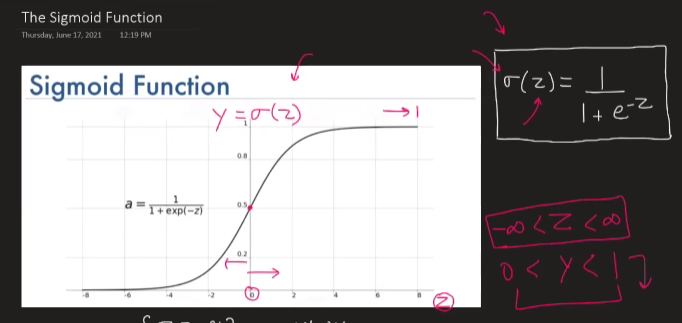

$$
\hat{y} = sigmoid(\mathbf{w}^T \mathbf{x})
$$ 

- So if the value of $\mathbf{w}^T \mathbf{x}$ is > 0, then $\hat{y}$ will be greater than 0.5, which means the point is classified as positive class, and if the value of $\mathbf{w}^T \mathbf{x}$ is < 0, then $\hat{y}$ will be less than 0.5, which means the point is classified as negative class.

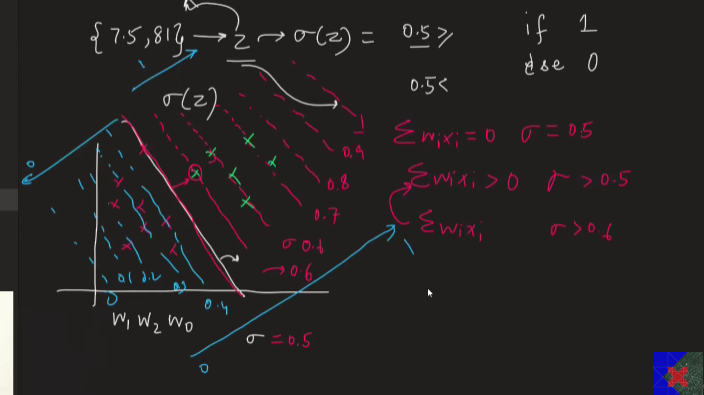

- **As you can see in the pic, that sigmoid function is also creating the whole region into gradient between 0 and 1, which means that the points which are closer to the line will have $\hat{y}$ value closer to 0.5, and the points which are farther from the line will have $\hat{y}$ value closer to 0 (to the negative side) or 1 (to the positive side).**

### Sigmoid is also kind of telling us probability of the point getting placement !!!!!

- Earlier , any point to the positive region was classified as 1 (got placed) and any point to the negative region was classified as 0 (not got placed)

- But now, with sigmoid function, we can say that if the point lie in th line ($\mathbf{w}^T \mathbf{x} = 0$), then $\hat{y}$ will be 0.5, which means that the point has 50% probability of getting placed

- And if the point lie in the positive region ($\mathbf{w}^T \mathbf{x} > 0$), then $\hat{y}$ will be greater than 0.5, which means that the point has more than 50% probability of getting placed, and if the point lie in the negative region ($\mathbf{w}^T \mathbf{x} < 0$), then $\hat{y}$ will be less than 0.5, which means that the point has less than 50% probability of getting placed.

- Far the point from the line in the positive region, higher the probability of getting placed, and far the point from the line in the negative region, lower the probability of getting placed.

- ### So, the gradien that is formed, is placement hone ka gradient hai in the range

- ### So, sigmoid function ko laane se puri cheez probability mei convert ho gyi, and we will use this probabilistic interpretation to update the weights for both misclassified and correctly classified points.

- Also, as each line is a tells us the ```probability of getting placed = P```

- So , ```probability of not getting placed = 1 - P```

# Change in the formula for updating the weights:

- Calculate $$Z = \mathbf{w}^T \mathbf{x}$$ for each point

### As $Z$ is similar to the distance of the point from the line (just without the normalization), so far the point from the line, higher the value of $Z$, and closer the point to the line, lower the value of $Z$.

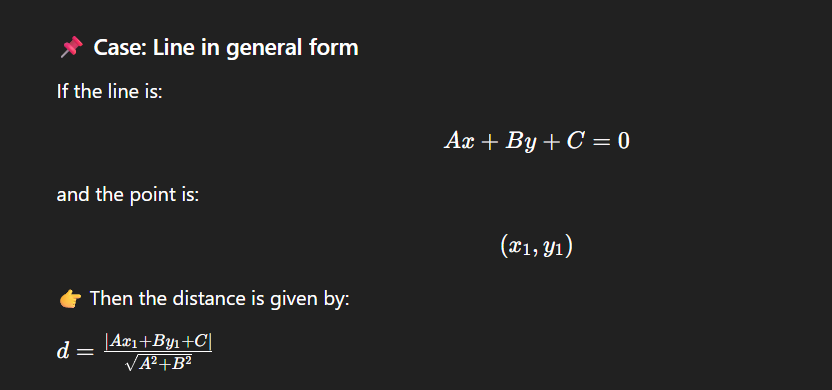

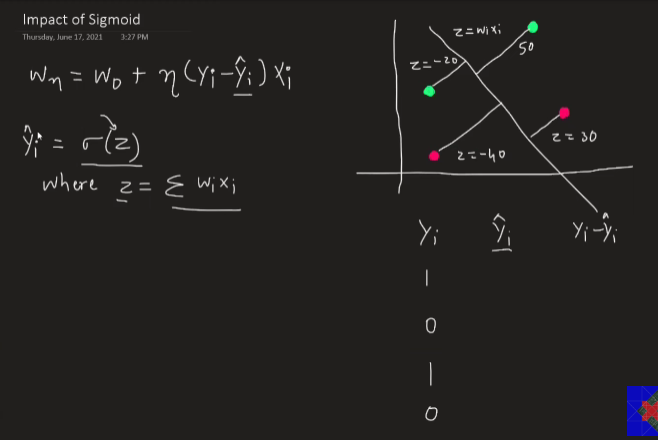

- Based on the distance we calculated the $\hat{y}$ value (sigmoid(Z))

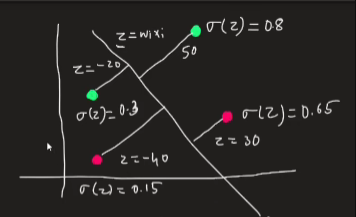

- Calculate $(y - \hat{y})$ , now its never 0 for any point, because $\hat{y}$ is never 0 or 1, it is always between 0 and 1, so we can update the weights for both misclassified and correctly classified points.

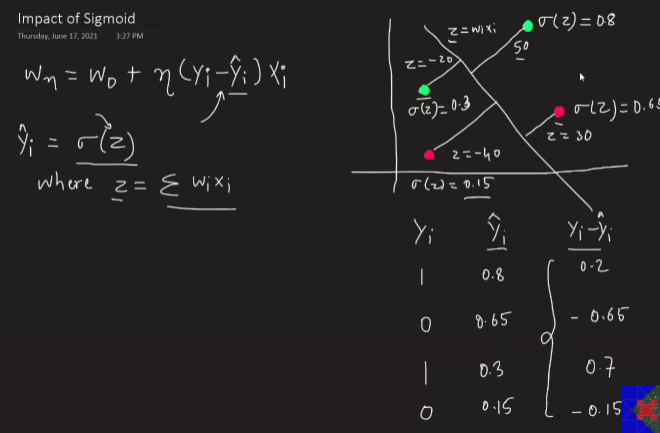

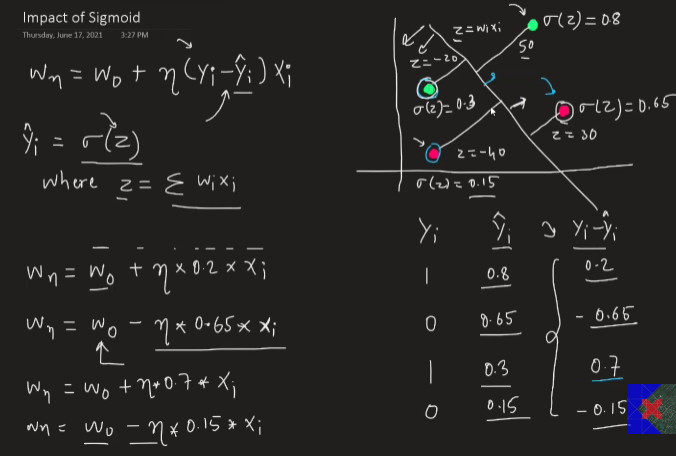

## <span style="color:orange">VVV IMPORTANT Discussion</span>

- So for point with $\hat{y} = 0.8$ (it is correctly classified point as $\hat{y} > 0.5$ and $y = 1$) (Right side green point in the pic)
    
    - So, here we are doing $W_{new} = W_{old} + \alpha (0.2) x$, so we are making the $W_{old}$ more positive, which leads to $\sum_{i=0}^{n} W_i X_i$ being more positive, which means we are pushing the line away from the point, which is correct as it is a correctly classified point.

- But for point with $\hat{y} = 0.3$ (it is misclassified point as $\hat{y} < 0.5$ and $y = 1$) (Left side green point in the pic)
    
    - So, here we are doing $W_{new} = W_{old} + \alpha (0.7) x$, so we are trying to increase the $\sum_{i=0}^{n} W_i X_i$ value (bring its value from negative to positive) to make $\hat{y}$ > 0.5, which means we are trying to pull the line towards the point, which is correct as it is a misclassified point.

- Similarly we can see for the negative class points as well, that for correctly classified points, we are pushing the line away from the point, and for misclassified points, we are pulling the line towards the point.

### Is it pushing and pulling the line based on the distance of the point from the line ?

- Yes, you can see in the below pic, that for the correctly classified point which is closer to the line, is pushing the line more than the correctly classified point which is farther from the line,

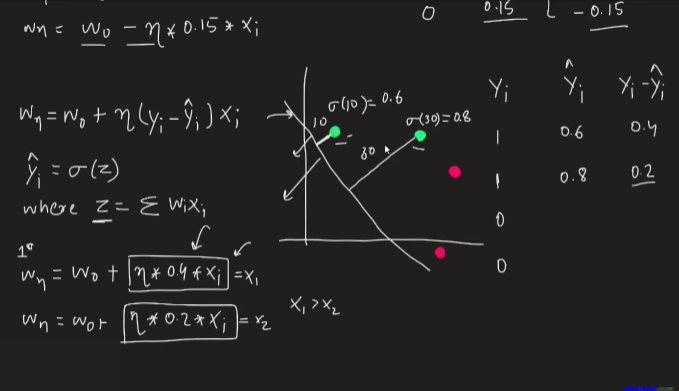

- Similarly for the misclassified points as well, the point which is closer to the line is pulling the line less than the point which is farther from the line.

- Let's see the code:

In [2]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [3]:
import matplotlib.pyplot as plt

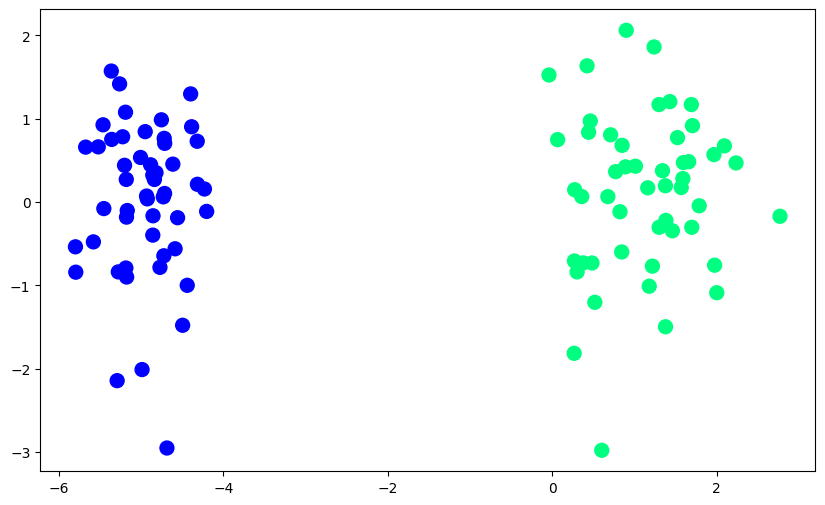

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [26]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [6]:
def step(z):
    return 1 if z>0 else 0

In [7]:
intercept_,coef_ = perceptron(X,y)

In [8]:
print(coef_)
print(intercept_)

[1.1134548  0.33857969]
1.3000000000000003


In [9]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

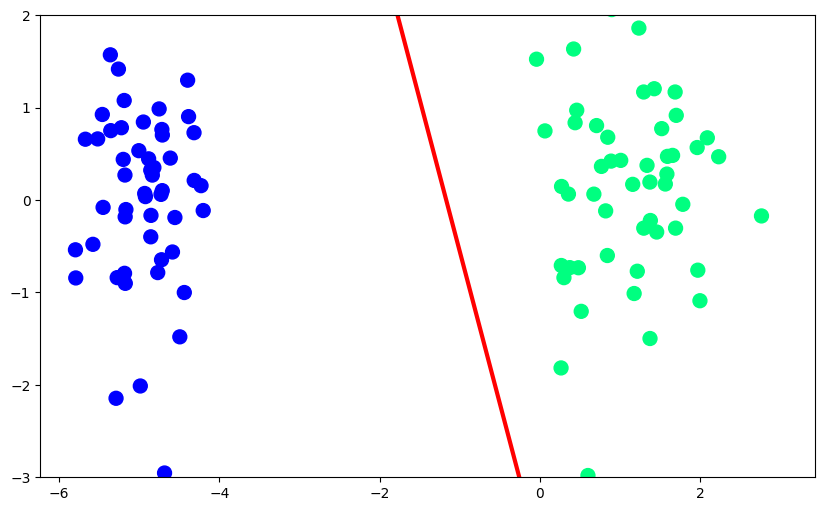

In [11]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [12]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [14]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

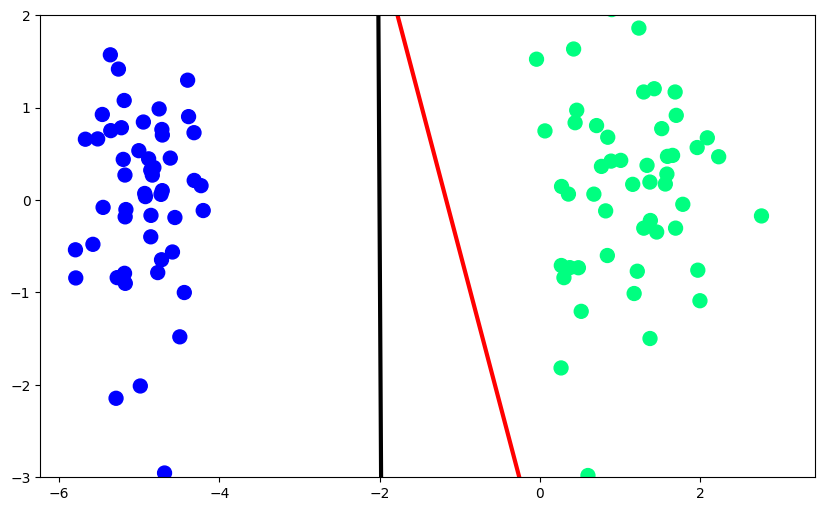

In [15]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

- Now rather than using step function, lets use sigmoid function to calculate $\hat{y}$, and then update the weights based on the formula we derived above.

In [16]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [17]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [18]:
intercept_,coef_ = perceptron(X,y)

In [19]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [20]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

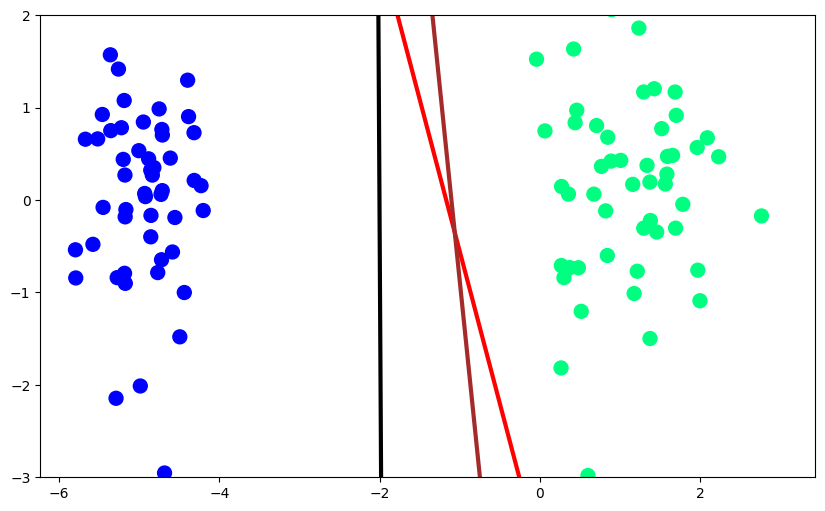

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3) # step function
plt.plot(x_input1,y_input1,color='black',linewidth=3) # sklearn's logistic regression
plt.plot(x_input2,y_input2,color='brown',linewidth=3) # sigmoid function
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

- So still you can see, the sklearn's logistic regression is also doing better than the perceptron algorithm, even after using sigmoid function

- So, it must be using some other optimization technique to find the optimal hyperplane, which we will see in the next lessson.

In [22]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [23]:
m,b = perceptron(X,y)

In [24]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [27]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save('perceptron_animation.gif', writer='pillow', fps=10)

<IPython.core.display.Javascript object>

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
